# Discriminant Analysis: In-Depth Investigation

In this notebook, we explore how Linear and Quadratic Discriminant Analysis models student depression.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')


## 1. Data Pre-Processing and Leakage Prevention
Just as we observed in previous analyses (like `main.ipynb`), leaving variables like `'Have you ever had suicidal thoughts ?'` in the dataset constitutes **Data Leakage**. It is highly correlated with depression and prevents the model from uncovering systemic causes (like academic pressure or financial stress). We will explicitly remove it.


In [2]:
# Load original dataset
try:
    df = pd.read_csv('dataset.csv')
except FileNotFoundError:
    print("Dataset not found.")

if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)

# Data Leakage Prevention
# If the model predicts depression solely because someone has suicidal thoughts, it isn't very useful for proactive intervention.
if 'Have you ever had suicidal thoughts ?' in df.columns:
    print("Dropping 'Have you ever had suicidal thoughts ?' to avoid data leakage.")
    df.drop(columns=['Have you ever had suicidal thoughts ?'], inplace=True)

# Handle Missing Values
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('Depression', errors='ignore')
cat_cols = df.select_dtypes(include=['object']).columns

# Simple median & mode imputation
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Encoding and Feature Target Split
X = df.drop(columns=['Depression'])
y = df['Depression']

# One-hot encode dropping the first level to minimize collinearity
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Pre-Processing Complete. Features formulated:", len(X_train_scaled.columns))


Dropping 'Have you ever had suicidal thoughts ?' to avoid data leakage.
Pre-Processing Complete. Features formulated: 108


## 2. In-Depth Linear Discriminant Analysis (LDA)
LDA assumes that features are normally distributed and that all classes share the exact same covariance matrix. Instead of merely looking at accuracy, we want to know *which* features LDA is actually utilizing to discriminate between a depressed and non-depressed student.


In [3]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

# Predictions and Accuracy
lda_pred = lda.predict(X_test_scaled)
print(f"LDA Base Accuracy: {accuracy_score(y_test, lda_pred):.4f}")


LDA Base Accuracy: 0.7970


### 2.1 Feature Importance via LDA Coefficients
Because LDA creates a linear decision boundary, the coefficients of its discriminant directly correspond to feature importance (similar to Logistic Regression or Lasso). Let's plot the top determining factors.


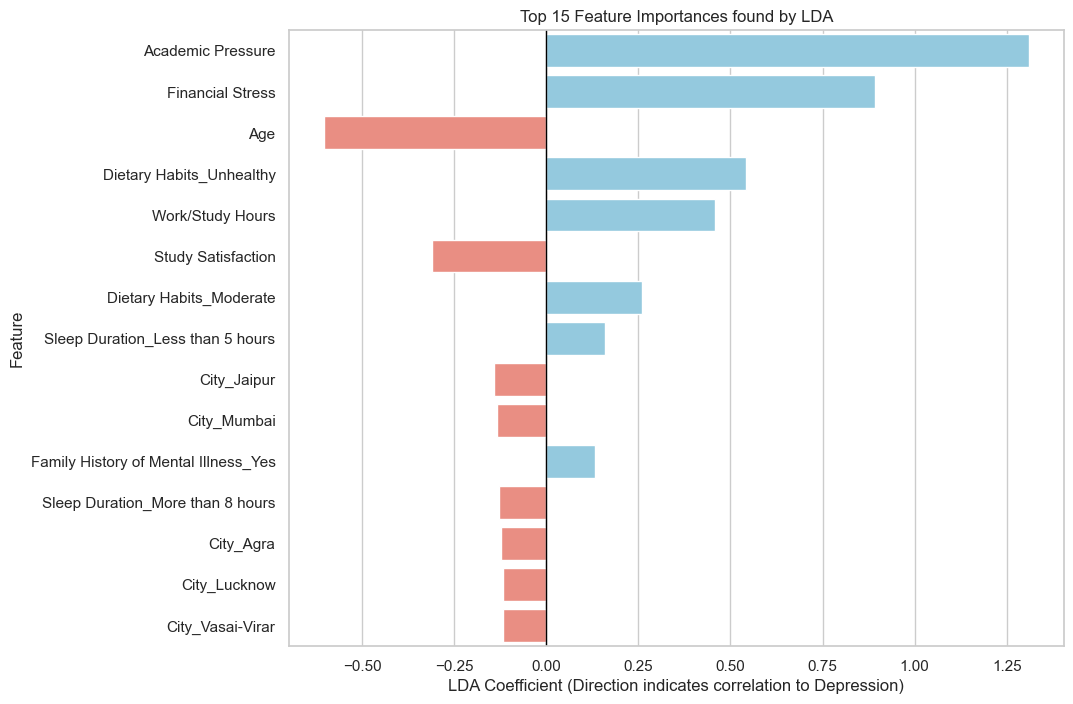

In [7]:
# Extract weights of the first (and only) linear discriminant for binary classification
lda_coefs = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lda.coef_[0]
})

# Calculate absolute importance for sorting
lda_coefs['Absolute_Importance'] = lda_coefs['Coefficient'].abs()
lda_coefs = lda_coefs.sort_values(by='Absolute_Importance', ascending=False)

# Safely build the color palette as a Python list
colors = ['salmon' if x < 0 else 'skyblue' for x in lda_coefs['Coefficient'].head(15)]

# Plot Top 15 Features
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=lda_coefs.head(15), 
    palette=colors
)
plt.title("Top 15 Feature Importances found by LDA")
plt.xlabel("LDA Coefficient (Direction indicates correlation to Depression)")
plt.ylabel("Feature")
plt.axvline(0, color='black', linewidth=1)
plt.show()


### 2.2 Dimensionality Reduction and Visualizing the Decision Space
 Since we have 2 classes, LDA projects all students onto a single 1-Dimensional Line. We can plot histograms of this projection to visualize the true class separation and understand where the model is confident versus where it is uncertain.


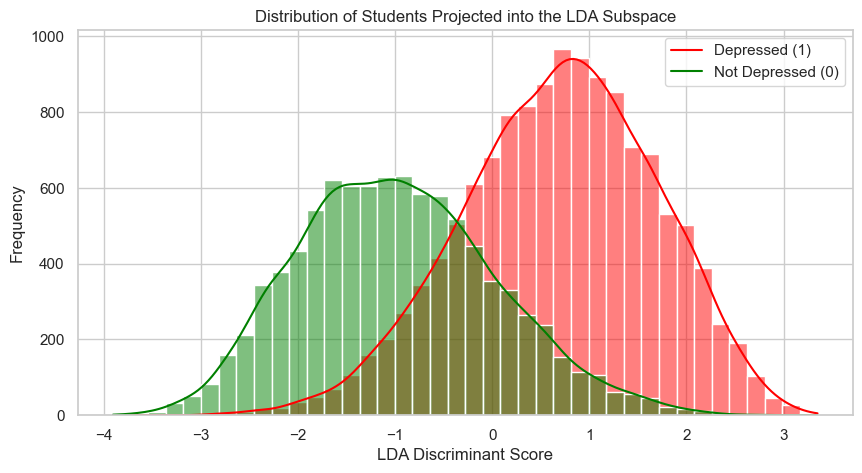

In [8]:
# Transform data into the 1D LDA space
X_train_lda = lda.transform(X_train_scaled).flatten()

# Create a DataFrame for easiest plotting
lda_proj_df = pd.DataFrame({
    'LDA_Score': X_train_lda,
    'Actual_Depression': y_train
})

plt.figure(figsize=(10, 5))
sns.histplot(data=lda_proj_df, x='LDA_Score', hue='Actual_Depression', kde=True, bins=40, palette=['green', 'red'], alpha=0.5)
plt.title("Distribution of Students Projected into the LDA Subspace")
plt.xlabel("LDA Discriminant Score")
plt.ylabel("Frequency")
plt.legend(['Depressed (1)', 'Not Depressed (0)'])
plt.show()


## 3. Advanced Quadratic Discriminant Analysis (QDA)
QDA relaxes the LDA constraint, allowing each class to have its own unique covariance matrix. This means it can capture complex feature interactions.

However, estimating multiple covariance matrices is highly susceptible to collinearity—especially when using sparse dummy variables. We will perform Grid Search to find the optimal `reg_param` (shrinkage) mathematically, preventing matrix singularity while tuning the model.


In [9]:
# Search for the optimal regularization parameter
qda_params = {
    'reg_param': [0.0001, 0.001, 0.01, 0.1, 0.3, 0.5, 0.8]
}

# 5-Fold Cross Validation tuning
qda_grid = GridSearchCV(QuadraticDiscriminantAnalysis(), qda_params, cv=5, scoring='accuracy')
qda_grid.fit(X_train_scaled, y_train)

best_qda = qda_grid.best_estimator_

print(f"Optimal QDA Regularization Parameter (reg_param): {qda_grid.best_params_['reg_param']}")

# Final QDA Evaluation
qda_pred = best_qda.predict(X_test_scaled)
print(f"Regularized QDA Accuracy: {accuracy_score(y_test, qda_pred):.4f}")


Optimal QDA Regularization Parameter (reg_param): 0.8
Regularized QDA Accuracy: 0.6984


### 3.1 Confusion Matrix Comparison
visually comparing what kind of mistakes our Tuned QDA is making versus the Linear LDA.


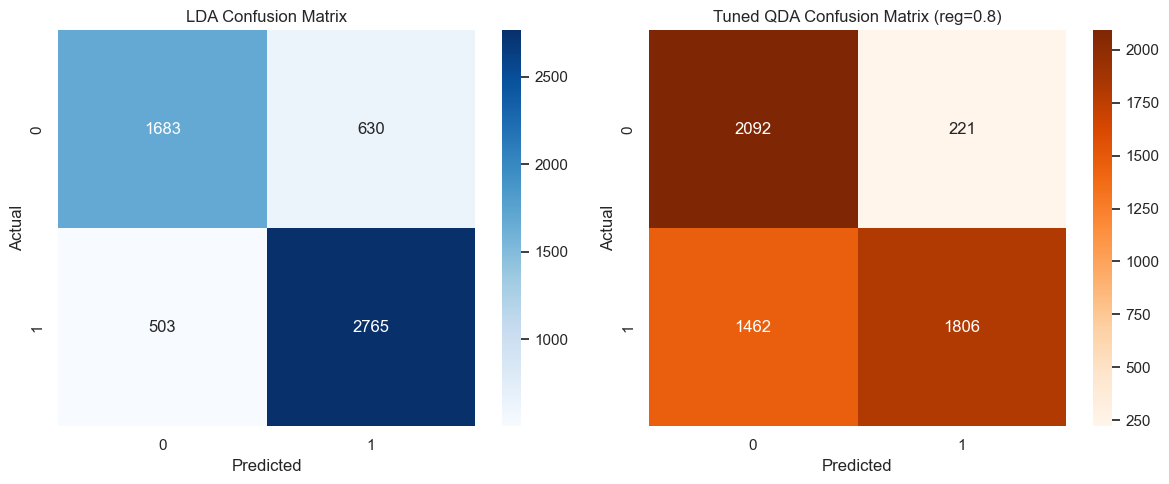

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, lda_pred), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('LDA Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, qda_pred), annot=True, fmt='d', cmap='Oranges', ax=ax[1])
ax[1].set_title(f'Tuned QDA Confusion Matrix (reg={qda_grid.best_params_["reg_param"]})')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()
